## <b>Conditioning Experiment (using MultiScale Laplacian Problem)</b>

### Study Motivation:

The conditioning property of the random feature matrix appears during least-square based optimization for <b>Random Feature Methods</b> significantly effects the runtime of the least squares solver during training and the resulting approximation error.

According to https://link.springer.com/article/10.1007/s42967-024-00389-8 better conditioning property implies faster runtime and lower approximation error, and it is indicated from the slow decay of the singular values of the random feature matrix here we called $M$. 

This experiment is designed to investigate how the condition property of the random feature matrix M changes for all types of SWIM-PDE models.

<b>Note:</b> This study is performed under function approximation setup, which means here the provided analytical solution of the problem below is tried to be approximated, instead of solving the PDE by operator evaluation. 

---
### Problem Definition:
As a base problem, the multiscale Laplacian problem is used with a difficulty of configuration 4 (see experiments/2D/multiscale_laplacian_weak_scaling.ipynb for details).

---
### Parametric Setup:

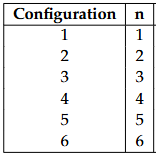

For the problem complexity configuration 4 is selected from the given table above.

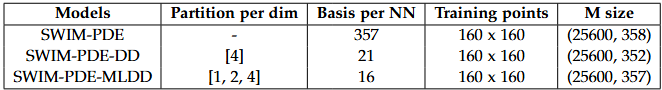

The model related parameters for each SWIM-PDE model is given in the table above. The number of basis function per subdomain SWIM networks for each model selected such that the total model capacity will be close as much as possible for each model as it can be seen from the size of random feature matrix $M$.

---


In [1]:
from swimpde_jax.domain import MultiLevelDecomposedDomain
from swimpde_jax.solver import DomainDecomposedStaticSolver
from swimpde_jax.boundary import Dirichlet
from swimpde_jax.ansatz import DecomposedBasicAnsatz
from swimpde_jax.equation import Laplacian

from numpy.linalg import svd
import numpy as np
import numpy.typing as npt
import jax.numpy as jnp
from jax.typing import ArrayLike

from functools import partial
import time

import matplotlib.pyplot as plt

### CONDITIONING STUDY

In this study we will investigate that how domain decomposition effects conditioning properties of a global matrix of the problem.

#### Configurations

1. Without domain partition
2. With domain partition in 1 level
3. With domain partition in multiple level

Note: In each setup we will determine the number of neurons for networks such that the global matrix will have approximately same size.

### Problem Definition   (Closed form solution of Laplacian)

In [2]:
def laplacian_target(x: npt.ArrayLike, n_basis: int) -> npt.ArrayLike:
    """ Analytical solution definition."""
    coeffs = 2 ** np.arange(1, n_basis + 1)  
    sin_x1 = np.sin(np.outer(coeffs, np.pi * x[:, 0]))  
    sin_x2 = np.sin(np.outer(coeffs, np.pi * x[:, 1]))  

    solution = np.sum(sin_x1 * sin_x2, axis=0)  
    return ((1 / n_basis) * solution)[:, None]

def laplacian_forcing(x: npt.ArrayLike, n_basis: int) -> npt.ArrayLike:
    """ Source function definition."""
    coeffs = 2 ** np.arange(1, n_basis + 1)  
    omega_pi_squared = (coeffs * np.pi) ** 2  
    sin_x1 = np.sin(np.outer(coeffs, np.pi * x[:, 0]))  
    sin_x2 = np.sin(np.outer(coeffs, np.pi * x[:, 1])) 

    forcing = np.sum(omega_pi_squared[:, None] * sin_x1 * sin_x2, axis=0)  
    return ((2 / n_basis) * forcing)[:, None]

def constraining_operator(points: ArrayLike, sigma=0.2) -> ArrayLike:
    """
    [Cu](x) = tanh(x1/σ) tanh((1−x1)/σ) tanh(x2/σ) tanh((1−x2)/σ)
    """
    x, y = points[0], points[1]
    return (
        jnp.tanh(x / sigma) *
        jnp.tanh((1 - x) / sigma) *
        jnp.tanh(y / sigma) *
        jnp.tanh((1 - y) / sigma)
    )

In [3]:
# Configurations for determining problem difficulty
problem_configs = {
    1 : {"num_sin_basis": 1},
    2 : {"num_sin_basis": 2},
    3 : {"num_sin_basis": 3},
    4 : {"num_sin_basis": 4},
    5 : {"num_sin_basis": 5},
    6 : {"num_sin_basis": 6},
}

In [4]:
# General settings and dataset creation
DIFFICULTY = 2  # Problem difficulty

random_state = 17
domain_span = (
        [0, 0], # lower bounds
        [1, 1]  # upper bounds
    )
n_dim = len(domain_span)
num_points_per_dim_train = 350

# Creation of training set
x_train = np.linspace(domain_span[0][0], domain_span[1][0],  num_points_per_dim_train)
y_train = np.linspace(domain_span[0][1], domain_span[1][1],  num_points_per_dim_train)
train_inputs = np.stack(np.meshgrid(x_train, y_train), axis=-1).reshape(-1, n_dim)
train_targets = laplacian_target(
    x=train_inputs, 
    n_basis=problem_configs[DIFFICULTY]['num_sin_basis'])

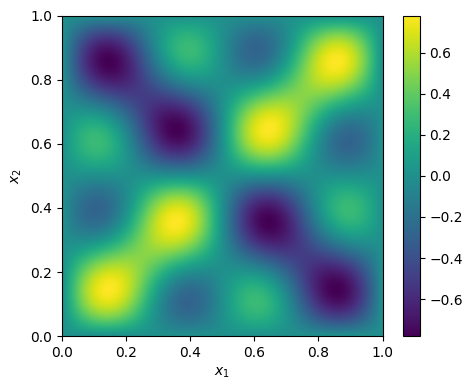

In [5]:
# Exact solution visualization
def plot_target(x: npt.ArrayLike, title=None):
    fig, ax = plt.subplots(figsize=(5, 4))
    vmin = np.nanmin(x)
    vmax = np.nanmax(x)
    im = ax.imshow(x, extent=[0, 1, 0, 1], vmin=vmin, vmax=vmax, origin='lower', cmap='viridis')
    if title:
        ax.set_title(title)
    plt.xlabel(r'$x_1$')
    plt.ylabel(r'$x_2$')
    fig.colorbar(im, ax=ax, orientation='vertical')
    plt.tight_layout()
    plt.show()

plot_target(train_targets.reshape(num_points_per_dim_train, -1))


### SOLUTION

In [6]:
def calculate_num_subdomain(partition, n_dim):
    return int(np.sum(np.array(partition)**n_dim))

In [7]:
# User defined settings
regular_partition = [1]
one_level_partition = [4]
multilevel_partition = [1, 2, 4]

num_subdomain_regular = calculate_num_subdomain(regular_partition, n_dim=n_dim)
num_subdomain_one_level = calculate_num_subdomain(one_level_partition, n_dim=n_dim)
num_subdomain_multi_level = calculate_num_subdomain(multilevel_partition, n_dim=n_dim)

num_basis_for_wo_partition_nn = num_subdomain_one_level * num_subdomain_multi_level
num_basis_for_one_level_nns = num_subdomain_multi_level 
num_basis_for_multi_level_nns = num_subdomain_one_level

solution_configs ={
    "Frozen-PINN-swim": {
        "partition": [1], # 1 subdomain (the domain itself)
        "num_swim_basis": num_basis_for_wo_partition_nn,
        "num_subdomains": num_subdomain_regular,
        "num_total_swim_basis": num_basis_for_wo_partition_nn * num_subdomain_regular
        },
    "Frozen-PINN-swim-DD":{
        "partition": one_level_partition,
        "num_swim_basis": num_basis_for_one_level_nns,
        "num_subdomains": num_subdomain_one_level,
        "num_total_swim_basis": num_basis_for_one_level_nns * num_subdomain_one_level
        },
    "Frozen-PINN-swim-MLDD":{
        "partition":  multilevel_partition,
        "num_swim_basis": num_basis_for_multi_level_nns,
        "num_subdomains": num_subdomain_multi_level,
        "num_total_swim_basis": num_basis_for_multi_level_nns * num_subdomain_multi_level
        },
}

overlap_ratio = 1.9
window_fn = "gaussian"
swim_activation = "tanh"
swim_param_sampler = "tanh"
swim_svd_cutoff = None
solver_type = "lstsq" # ["lstsq", "lsrn", "lsqr", "lsmr", "dask_svd"]
use_disk = False
regularization_scale = 1e-12


In [8]:
solution_configs

{'Frozen-PINN-swim': {'partition': [1],
  'num_swim_basis': 336,
  'num_subdomains': 1,
  'num_total_swim_basis': 336},
 'Frozen-PINN-swim-DD': {'partition': [4],
  'num_swim_basis': 21,
  'num_subdomains': 16,
  'num_total_swim_basis': 336},
 'Frozen-PINN-swim-MLDD': {'partition': [1, 2, 4],
  'num_swim_basis': 16,
  'num_subdomains': 21,
  'num_total_swim_basis': 336}}

In [13]:
# Solution loop for SWIM-PDE
boundary_mask = (
    (train_inputs[:, 0] == domain_span[0][0]) |
    (train_inputs[:, 0] == domain_span[1][0]) |
    (train_inputs[:, 1] == domain_span[0][1]) |
    (train_inputs[:, 1] == domain_span[1][1])  
)

equation = Laplacian()

forcing_function = partial(laplacian_forcing, n_basis=problem_configs[DIFFICULTY]['num_sin_basis'])

boundary_condition = Dirichlet(g=forcing_function)

singular_values_dict = dict()
for sol_type, sol_config in solution_configs.items():
    
    domain = MultiLevelDecomposedDomain(
        interior_points=train_inputs[~boundary_mask],
        boundary_points=train_inputs[boundary_mask],
        num_partition_per_level=sol_config['partition'],
        overlap_ratio=overlap_ratio, 
        window_fn=window_fn,
    )
    
    ansatz = DecomposedBasicAnsatz(
        n_basis=sol_config['num_swim_basis'],
        activation=swim_activation,
        random_seed=random_state,
        svd_cutoff=swim_svd_cutoff,
        constraining_operator=partial(constraining_operator, sigma=2**DIFFICULTY),
        parameter_sampler=swim_param_sampler
    )
    
    solver = DomainDecomposedStaticSolver(
        domain=domain,
        ansatz=ansatz,
        boundary_condition=boundary_condition,
        equation=equation,
        f=forcing_function, 
        regularization_scale=regularization_scale,
        solver=solver_type,
        use_disk=use_disk,
    )
    
    # Perform training
    start_fit = time.time()
    _, global_matrix = solver.fit()
    end_fit = time.time()
    training_time = end_fit - start_fit
    
    singular_values = svd(global_matrix, compute_uv=False)
    singular_values_dict[f"{sol_type}"] = singular_values
    #singular_values_dict[f"{sol_type}: M.shape = {global_matrix.shape}, Partition = {sol_config['partition']}, Num Basis per NN= {sol_config['num_swim_basis']}"] = singular_values

Initializing local SWIM networks...


Processing decomposed domains: 100%|██████████| 1/1 [00:00<00:00,  1.82domain/s]


All local networks are initialized.
Solving global system...
Assigning found coefficients to corresponding local networks...
SWIM network creations are completed.
Initializing local SWIM networks...


Processing decomposed domains: 100%|██████████| 1/1 [00:09<00:00,  9.50s/domain]


All local networks are initialized.
Solving global system...
Assigning found coefficients to corresponding local networks...
SWIM network creations are completed.
Initializing local SWIM networks...


Processing decomposed domains: 100%|██████████| 3/3 [00:12<00:00,  4.07s/domain]


All local networks are initialized.
Solving global system...
Assigning found coefficients to corresponding local networks...
SWIM network creations are completed.


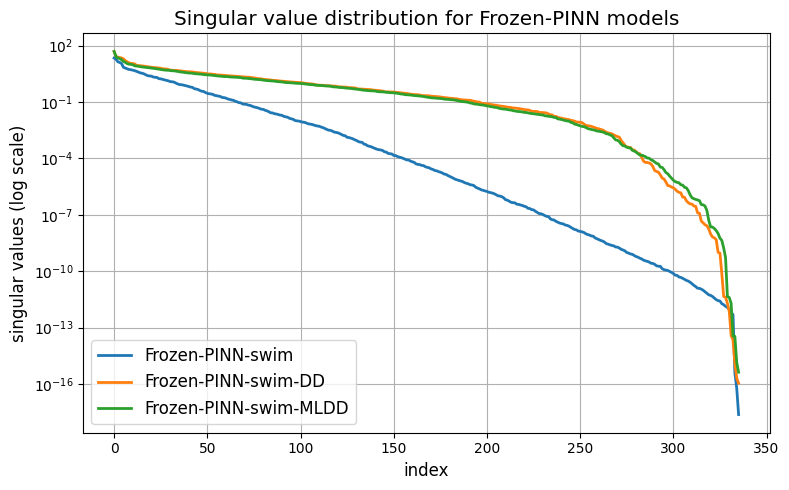

In [16]:
def plot_singular_values(singular_values_dict, title, x_label="index", y_label="singular value", y_range=None):
    plt.figure(figsize=(8, 5))
    for label, eigvals in singular_values_dict.items():
        plt.semilogy(eigvals, label=label, linewidth=2)
    
    plt.xlabel(x_label, fontsize="large")
    plt.ylabel(y_label, fontsize="large")
    if y_range is not None:
        plt.ylim(y_range)
    plt.title(title,fontsize="x-large")
    plt.grid(True)
    plt.legend(fontsize="large")
    plt.tight_layout()
    plt.show()

plot_singular_values(
    singular_values_dict, 
    title="Singular value distribution for Frozen-PINN models",
    y_label="singular values (log scale)",
    x_label="index",
    y_range = None #[1e-18, 1e6]
    )

###  Evaluation

The result of the performed experiment shows that the singular values of the random feature matrix $M$ decay more slowly for the domain-decomposed SWIM-PDE models compared to the
standard SWIM-PDE model. From this observation, it can be concluded that incorporating domain decomposition with a partition of unity significantly enhances the conditioning of the random feature matrix $M$ within the SWIM-PDE framework, consistent with expectations for RFM-based models [see https://link.springer.com/article/10.1007/s42967-024-00389-8]. This result highlights that domain-decomposed SWIM-PDE models improve not only in terms of solution accuracy and scalability but also in the numerical stability and efficiency of the training process. 

However, further comparison between the one-level and multilevel domain-decomposed configurations reveals additional insights. Although they both benefit from domain decomposition, the multilevel configuration introduces a noticeably sharper decay in the singular values of the feature matrix $M$. This indicates that the multilevel model may generate a higher number of near-zero singular values, which reflects an increase in redundancy and a reduction in the effective rank of $M$. As a result, despite its finer-grained representation and improved local expressiveness, the multilevel model exhibits worse conditioning than the one-level model, indicating it may require more careful numerical treatment to ensure numerical stability in solving the resulting least-squares problem.